## Stanisław Wojciechowski
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vyenn/ML2024/blob/main/homework6.ipynb)

## Answers

**Equivalence Analysis**
- local RSS minimalization
$$
   (X_j^*, t^*) = \arg\min_{X_j, t} \sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2.
   $$
and RSS gain maximization
$$
   (X_j^*, t^*) = \arg\max_{X_j, t} \Bigl\{
   \underbrace{\sum_{i : x_i \in \text{Parent}} (y_i - \bar{y})^2}_{\text{Parent RSS}}
   \;-\;
   \underbrace{\sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2}_{\text{Children RSS}}
   \Bigr\}.
   $$
are equivalent. Indeed, parent RSS in the context of gain maximization is constant (with respect to $X_j$ and $t$), so
$$\arg\max(\text{parent RSS} - \text{children RSS}) = \arg\max (-\text{children RSS}) = \arg\min(\text{children RSS}).$$

- total RSS minimization is distinct, as it minimizes the global RSS across the whole tree rather than focusing on a single parent-child split.

**Explain why a hyperplane in 3D becomes a circular (or elliptical) curve when viewed back in the original 2D plane of the dataset.**
- a map $\phi$ is quadratic, its image is a cone. That's why when intersected with a hyperplane, we expect to see a circle,ellpise,parabola or a hyperbola.

## Empirical verification

- as we can see, scikit-learn’s DecisionTreeRegressor coincides with local RSS minimalization and differs from global RSS minimalization:

<ipython-input-20-4d745f383542>:50: RuntimeWarning: Mean of empty slice.
  rss = sum(np.sum((y[m] - y[m].mean())**2) for m in [m2_left, m2_right, m3_left, m3_right])
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


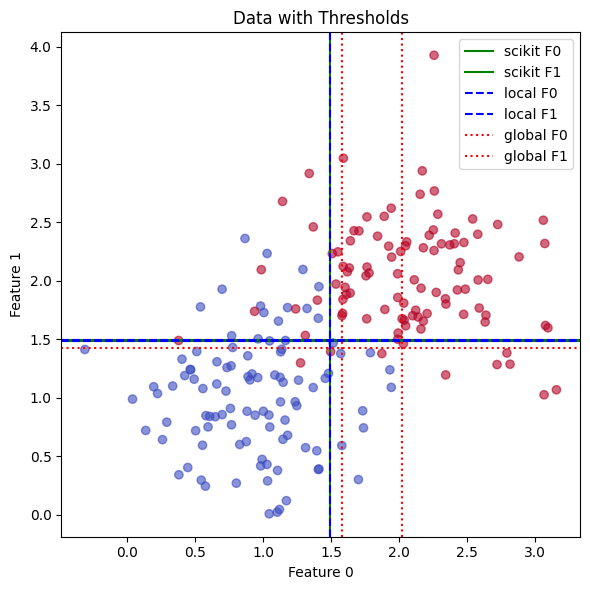

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from itertools import product

# Generate data
np.random.seed(42)
X1 = np.random.normal([1, 1], 0.5, (100, 2))
X2 = np.random.normal([2, 2], 0.5, (100, 2))
X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

# Scikit-learn thresholds
tree = DecisionTreeRegressor(max_depth=2).fit(X, y)
sk_thresholds = {i: [] for i in range(2)}
for i in range(tree.tree_.node_count):
    if tree.tree_.children_left[i] != -1:
        sk_thresholds[tree.tree_.feature[i]].append(tree.tree_.threshold[i])

# Local recursive regression
class LocalRR:
    def __init__(self, max_depth=2): self.max_depth = max_depth; self.thresholds = {0: [], 1: []}
    def find_split(self, X, y, d=0):
        if d >= self.max_depth: return
        best = min(((f, t := (v[i]+v[i+1])/2,
                     np.sum((y[X[:,f]<=t] - y[X[:,f]<=t].mean())**2) +
                     np.sum((y[X[:,f]>t] - y[X[:,f]>t].mean())**2), X[:,f]<=t)
                    for f in [0,1] for v in [np.unique(X[:,f])] for i in range(len(v)-1)),
                   key=lambda x: x[2], default=(None,None,float('inf'),None))
        f, t, _, m = best
        if f is not None:
            self.thresholds[f].append(t)
            self.find_split(X[m], y[m], d+1)
            self.find_split(X[~m], y[~m], d+1)

local_rr = LocalRR()
local_rr.find_split(X, y)

# Global RR (simplified exhaustive)
T = {f: np.unique([np.percentile(X[:, f], p) for p in np.linspace(10, 90, 10)]) for f in [0, 1]}
candidates = [(f, t) for f in [0, 1] for t in T[f]]
best_rss, best_tree = np.inf, None

for (f1, t1), (f2, t2), (f3, t3) in product(candidates, repeat=3):
    m1 = X[:, f1] <= t1
    m2_left = m1 & (X[:, f2] <= t2)
    m2_right = m1 & (X[:, f2] > t2)
    m3_left = ~m1 & (X[:, f3] <= t3)
    m3_right = ~m1 & (X[:, f3] > t3)
    rss = sum(np.sum((y[m] - y[m].mean())**2) for m in [m2_left, m2_right, m3_left, m3_right])
    if rss < best_rss:
        best_rss = rss
        best_tree = {0: [], 1: []}
        for f, t in [(f1, t1), (f2, t2), (f3, t3)]:
            best_tree[f].append(t)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("Data with Thresholds")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

colors = {'scikit': 'green', 'local': 'blue', 'global': 'red'}
linestyles = {'scikit': '-', 'local': '--', 'global': ':'}
seen_labels = set()

for name, thresh in zip(['scikit', 'local', 'global'],
                        [sk_thresholds, local_rr.thresholds, best_tree]):
    for f in [0, 1]:
        for t in thresh.get(f, []):
            label = f'{name} F{f}'
            if label not in seen_labels:
                seen_labels.add(label)
                (plt.axvline if f == 0 else plt.axhline)(t, color=colors[name], linestyle=linestyles[name], label=label)
            else:
                (plt.axvline if f == 0 else plt.axhline)(t, color=colors[name], linestyle=linestyles[name])

plt.legend()
plt.tight_layout()
plt.show()
